In [ ]:
!pip -q install amplpy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 5.1 MB/s eta 0:00:00


In [ ]:
# 1. Instalación e inicialización de AMPL con tu licencia Community Edition
from amplpy import ampl_notebook

# Inicializa AMPL en Colab con tu UUID (Community Edition) Inicializar AMPL
ampl = ampl_notebook(
    modules=["highs", "cbc", "gurobi", "cplex"],  # solvers disponibles
    license_uuid="936b618d-a013-406f-9809-49679f557c26"
)

Licensed to AMPL Academic Community Edition License for <m.godoyseplveda@uandresbello.edu>.


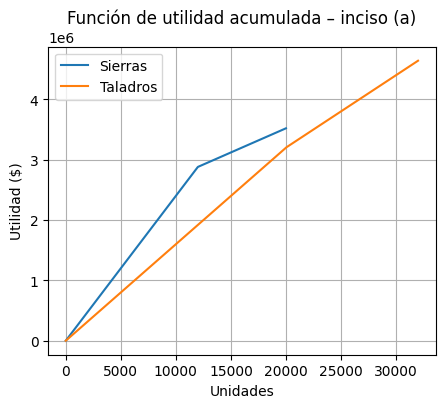

In [ ]:
import numpy as np, matplotlib.pyplot as plt

# puntos de quiebre
S_break = [0, 12000, 20000]       # 12k normales + 8k extra
T_break = [0, 20000, 32000]       # 20k normales + 12k extra

def U_s(x):    # utilidad sierras
    return np.where(x<=12000, 240*x,
                    240*12000 + 80*(x-12000))

def U_t(x):    # utilidad taladros
    return np.where(x<=20000, 160*x,
                    160*20000 + 120*(x-20000))

xs = np.linspace(0, 20000, 400)
xt = np.linspace(0, 32000, 400)

plt.figure(figsize=(5,4))
plt.plot(xs, U_s(xs), label='Sierras')
plt.plot(xt, U_t(xt), label='Taladros')
plt.xlabel('Unidades'); plt.ylabel('Utilidad ($)')
plt.title('Función de utilidad acumulada – inciso (a)')
plt.grid(); plt.legend(); plt.show()


In [ ]:
%%writefile 12_8_3.mod
set K;                           # 0 = produccion normal, 1 = horas extra

param pS{K};                     # utilidad/unidad sierras
param pT{K};                     # utilidad/unidad taladros
param capS{K};                   # capacidad por tramo (sierras)
param capT{K};                   # capacidad por tramo (taladros)

var s{K} >= 0 <= capS[k];        # unidades sierras en tramo k
var t{K} >= 0 <= capT[k];        # unidades taladros en tramo k

var S = sum{k in K} s[k];        # total sierras
var T = sum{k in K} t[k];        # total taladros

maximize Z:
    sum{k in K} ( pS[k]*s[k] + pT[k]*t[k] );

s.t. Motores:   S + T      <= 40000;
s.t. Engranes:  2*S + T    <= 60000;


Overwriting 12_8_3.mod


In [ ]:
%%writefile 12_8_3.dat
# 2 tramos: k = 0 (normal) , k = 1 (horas extra)
set K := 0 1 ;

param pS :=
 0  240     # utilidad sierras producción normal
 1   80 ;   # utilidad sierras en horas extra

param pT :=
 0  160
 1  120 ;

param capS :=
 0  12000   # máximo sierras en turno normal
 1   8000 ; # máximo sierras en horas extra

param capT :=
 0  20000
 1  12000 ;


Writing 12_8_3.dat


In [ ]:
ampl.read('12_8_3.mod')
ampl.readData('12_8_3.dat')

ampl.option['solver'] = 'highs'      # CBC también sirve
ampl.solve()

ampl.display('S','T','Z','s','t')


HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 7040000
1 simplex iterations
0 barrier iterations
S = 12000
T = 28000
Z = 7040000

:     s       t      :=
0   12000   20000
1       0    8000
;

